### Installs and Imports

In [18]:
%pip install -q pandas
%pip install -q statsbombpy
%pip install -q networkx
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

import warnings
from statsbombpy.api_client import NoAuthWarning

# Filter out the specific StatsBomb NoAuthWarning
warnings.simplefilter("ignore", NoAuthWarning)

# Now import/run statsbombpy cleanly without the warning
from statsbombpy import sb

# Display configuration for clean output inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

/Users/lukebirkett/Repos/study-planner/981G5_Network_Science/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Competition Extraction

In [2]:
# Retrieve the competitions DataFrame
competitions_df = sb.competitions()
print(f"Total Competitions Returned: {len(competitions_df)}")

# Filter the DataFrame for WSL 2023/2024
target_filter = (competitions_df['competition_id'] == 37) & (competitions_df['season_id'] == 281)
wsl_competition = competitions_df[target_filter].to_dict(orient='records')[0]

# Print the extracted row
print("\nExtracted Competition Payload:")
print(wsl_competition)

Total Competitions Returned: 80

Extracted Competition Payload:
{'competition_id': 37, 'season_id': 281, 'country_name': 'England', 'competition_name': "FA Women's Super League", 'competition_gender': 'female', 'competition_youth': False, 'competition_international': False, 'season_name': '2023/2024', 'match_updated': '2026-04-11T13:05:10.794831', 'match_updated_360': None, 'match_available_360': None, 'match_available': '2026-04-11T13:05:10.794831'}


### Helper Functions

In [3]:
def parse_minute(val, default_val=0):
    """Safely extracts the minute integer from a StatsBomb 'from' or 'to' timestamp."""
    if val is None:
        return default_val
    if isinstance(val, (int, float)):
        return int(val)
    if isinstance(val, str) and ':' in val:
        return int(val.split(':')[0])  # Take 'MM' from 'MM:SS'
    try:
        return int(val)
    except ValueError:
        return default_val

In [4]:
def extract_11_players(player_list):
    """Used to turn a teams match roster into an 11 player list"""
    sorted_players = sorted(player_list, key=lambda x: x['Minutes Played'], reverse=True)
    top_11_players = sorted_players[:11]
    return top_11_players

### Match Extractions

Here is the current implementation of the code. What I have done is code an implementation which will extract 2 lists for every match. The lists contain a match_id, team_name, and a list containing the active players from the match. This player listed contains all players that entered the field but it contains a minutes players field so later on I can filter down to the 11. The purpose of this data structure is to give me a list that I can loop through. Each list represents the basis of a network, i.e. the fields can be used to extract the passes from events and the player level info establish the nodes

In [5]:
# Fetch WSL 2023/2024 Matches
COMPETITION_ID = 37
SEASON_ID = 281

matches_df = sb.matches(competition_id=COMPETITION_ID, season_id=SEASON_ID)
print(f"League contains {len(matches_df)} matches.")
match_records = []

for idx, match in matches_df.iterrows():
    m_id = match['match_id']
    events_df = sb.events(match_id=m_id)
    max_minute = int(events_df['minute'].max())
    lineups = sb.lineups(match_id=m_id)
    
    for team in lineups:
        roster = len(lineups[team]['player_id'].tolist())
        player_list = []

        # Extract Player Level Data
        for player_index in range(0,roster):
            if not lineups[team]['positions'][player_index]:
                pass
            else:
                start = lineups[team]['positions'][player_index][0]
                end = lineups[team]['positions'][player_index][-1]
                pos = start['position']
                # Started
                if start['start_reason'] == 'Starting XI':
                    started = 1
                    _from = 0
                    if start['end_reason'] == 'Final Whistle':
                        full_match = 1
                        to = max_minute
                    else:
                        if end['end_reason'] == 'Final Whistle':
                            full_match = 1
                            to = max_minute
                        else:
                            full_match = 0
                            to = parse_minute(end.get('to'), default_val=max_minute)
                # Didnt Start
                else: 
                    started = 0
                    _from = parse_minute(start.get('from'), default_val=max_minute)
                    if end['to']: # Didnt start and Didnt finish
                        to = parse_minute(end.get('to'), default_val=max_minute)
                    else:
                        to = max_minute
                    full_match = 0
                
                # player index
                pid = lineups[team]['player_id'].tolist()[player_index]
                pn = lineups[team]['player_name'].tolist()[player_index]

                player_dict = {
                    "Player Name": pn,
                    "Player ID": pid,
                    "Position": pos,
                    # "Started": started,
                    # "Full Match": full_match,
                    "Starting Minute": _from,
                    "Ending Minute": to,
                    "Minutes Played": (to-_from),
                }

                player_list.append(player_dict)

        match_records.append([idx, m_id, team, player_list])

League contains 132 matches.


In [7]:
print("Match Index", match_records[0][0])
print("Match ID", match_records[0][1])
print("Team Name", match_records[0][2])
print("Player List", match_records[0][3])

Match Index 0
Match ID 3913082
Team Name Brighton & Hove Albion WFC
Player List [{'Player Name': 'Maria Thorisdottir', 'Player ID': 4636, 'Position': 'Center Back', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'María Victoria Losada Gómez', 'Player ID': 10158, 'Position': 'Right Defensive Midfield', 'Starting Minute': 54, 'Ending Minute': 100, 'Minutes Played': 46}, {'Player Name': 'Tatiana Vanessa Ferreira Pinto', 'Player ID': 10167, 'Position': 'Left Midfield', 'Starting Minute': 95, 'Ending Minute': 100, 'Minutes Played': 5}, {'Player Name': 'Sophie Baggaley', 'Player ID': 16376, 'Position': 'Goalkeeper', 'Starting Minute': 0, 'Ending Minute': 100, 'Minutes Played': 100}, {'Player Name': 'Pauline Bremer', 'Player ID': 20725, 'Position': 'Left Wing', 'Starting Minute': 0, 'Ending Minute': 95, 'Minutes Played': 95}, {'Player Name': 'Katie Robinson', 'Player ID': 21059, 'Position': 'Right Wing Back', 'Starting Minute': 0, 'Ending Minute': 68, 'Min

### Match Supplementation (Total Passes and 11 Players)

In [8]:
integrated_match_records = []

for match_data in match_records:
    match_index, m_id, team_name, player_list = match_data
    
    events = sb.events(match_id=m_id)

    team_passes = events[
        (events['team'] == team_name) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) # successful pass
    ]

    total_team_passes = len(team_passes)

    extracted_players_list = extract_11_players(player_list)
    
    integrated_match_records.append([
        match_index, 
        m_id, 
        team_name, 
        total_team_passes, 
        player_list,
        extracted_players_list
    ])

sample_entry = integrated_match_records[0]

print("\nSample Enriched Match Record:")
print(f"Match Index:  {sample_entry[0]}")
print(f"Match ID:     {sample_entry[1]}")
print(f"Team Name:    {sample_entry[2]}")
print(f"Total Passes: {sample_entry[3]}")
print(f"Roster Count: {len(sample_entry[4])} players")
print(f"Active Count: {len(sample_entry[5])} players")
print("Top 3 Players in Roster:")
for p in sample_entry[5][:3]:
    print(f"  • {p['Player Name']} ({p['Position']}) - {p['Minutes Played']} mins")


Sample Enriched Match Record:
Match Index:  0
Match ID:     3913082
Team Name:    Brighton & Hove Albion WFC
Total Passes: 204
Roster Count: 16 players
Active Count: 11 players
Top 3 Players in Roster:
  • Maria Thorisdottir (Center Back) - 100 mins
  • Sophie Baggaley (Goalkeeper) - 100 mins
  • Emma Nanny Charlotte Kullberg (Left Wing Back) - 100 mins


### High-Level Statistics (Match and Passes)

In [9]:
total_matches = len(match_records)/2
total_team_games = len(match_records)

# Extract total unique active players per team per match (before truncation)
players_used_per_game = [len(m[3]) for m in match_records]

mean_players_used = np.mean(players_used_per_game)
min_players_used = np.min(players_used_per_game)
max_players_used = np.max(players_used_per_game)

# Calculate total season passes across all matches
total_passes = 0
passes_per_team_game = []

for match_data in integrated_match_records:
    match_index, m_id, team_name, total_team_passes, player_list, extracted_players_list = match_data
    
    pass_count = total_team_passes
    total_passes += pass_count
    passes_per_team_game.append(pass_count)

mean_passes = np.mean(passes_per_team_game)
min_passes = np.min(passes_per_team_game)
max_passes = np.max(passes_per_team_game)

# ==============================================================================
# 3. PRINT GENERATED TABLE STATS
# ==============================================================================
print("\n" + "=" * 60)
print("EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)")
print("=" * 60)
print(f"Total Matches Analyzed:                 {total_matches}")
print(f"Total Team Match Networks:              {total_team_games}")
print(f"Total Completed Season Passes:          {total_passes:,}")
print(f"Mean Passes per Team per Match:         {mean_passes:.1f} (Range: {min_passes} - {max_passes})")
print(f"Mean Unique Players Used per Game:      {mean_players_used:.1f} (Range: {min_players_used} - {max_players_used})")
# print("=" * 60)


EXTRACTED SUMMARY STATISTICS (WSL 2023/2024)
Total Matches Analyzed:                 132.0
Total Team Match Networks:              264
Total Completed Season Passes:          105,262
Mean Passes per Team per Match:         398.7 (Range: 120 - 847)
Mean Unique Players Used per Game:      15.1 (Range: 12 - 16)


### Highest Pass Match

In [10]:
# Returns a tuple: (list_index, max_record)
max_idx, highest_pass_match = max(
    enumerate(integrated_match_records), 
    key=lambda item: item[1][3]
)

print(f"Record Index: {max_idx}")
print(f"Match ID:     {highest_pass_match[1]}")
print(f"Team:         {highest_pass_match[2]}")
print(f"Passes:       {highest_pass_match[3]}")

Record Index: 60
Match ID:     3913160
Team:         Arsenal WFC
Passes:       847


### Network

PassMap Graph Successfully Built for Arsenal WFC (Match ID: 3913160)
• Nodes: 11 | Edges: 89 | Total Filtered Passes: 720


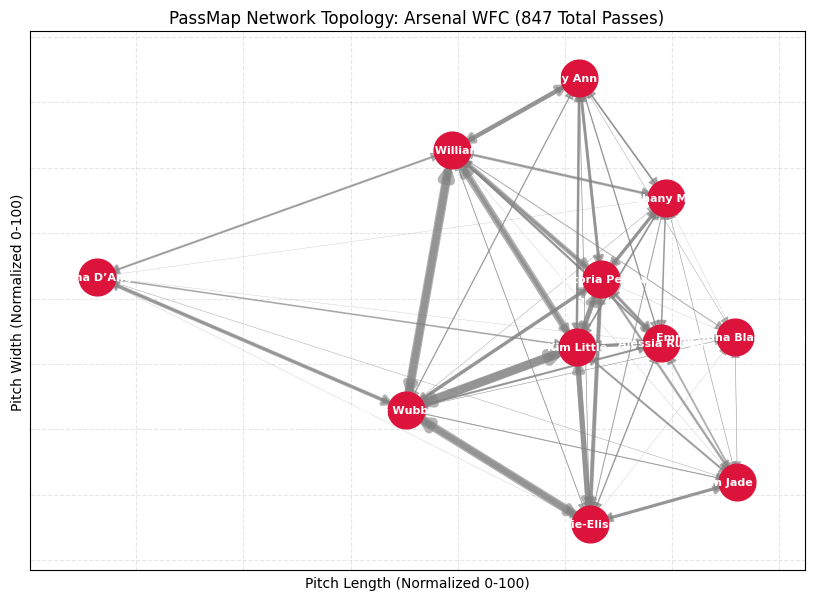

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
from statsbombpy import sb

def build_passmap_network(match_record):
    """
    Constructs a weighted, directed NetworkX graph (nx.DiGraph) for a team passmap.
    
    Parameters:
        match_record (list): An entry from integrated_match_records in the format:
            [match_index, match_id, team_name, total_passes, player_list, top_11_players]
            
    Returns:
        G (nx.DiGraph): Directed graph where nodes are player names/IDs with spatial coordinates (x,y)
                        and edges represent completed pass counts between player pairs.
    """
    
    # Unpack record
    _, m_id, team_name, _, _, top_11_players = match_record
    
    # Extract Top-11 Player IDs and create a mapping for fast filtering
    top_11_ids = {p['Player ID'] for p in top_11_players}
    player_id_to_name = {p['Player ID']: p['Player Name'] for p in top_11_players}
    
    # Fetch event stream for the match
    events = sb.events(match_id=m_id)
    
    # Filter for successful passes belonging exclusively to the target team and Top-11 players
    passes_df = events[
        (events['team'] == team_name) & 
        (events['type'] == 'Pass') & 
        (events['pass_outcome'].isna()) &
        (events['player_id'].isin(top_11_ids)) & 
        (events['pass_recipient_id'].isin(top_11_ids))
    ].copy()
    
    # Calculate Average Spatial Location (x, y) for each Top-11 player
    # This is the Node location in the pitch
    # Split StatsBomb 'location' list [x, y] into separate normalized coordinates (0-100 scale)
    passes_df['x'] = passes_df['location'].apply(lambda loc: (loc[0] / 120.0) * 100 if isinstance(loc, list) else None)
    passes_df['y'] = passes_df['location'].apply(lambda loc: (loc[1] / 80.0) * 100 if isinstance(loc, list) else None)
    avg_locations = passes_df.groupby('player_id')[['x', 'y']].mean().to_dict('index')
    
    # Initialize NetworkX Directed Graph
    G = nx.DiGraph()
    
    # Add Nodes with attributes (Name, Position, Average x,y)
    for p in top_11_players:
        p_id = p['Player ID']
        p_name = p['Player Name']
        p_pos = p['Position']
        loc = avg_locations.get(p_id, {'x': 50.0, 'y': 50.0})
        
        G.add_node(
            p_name,
            player_id=p_id,
            position=p_pos,
            pos=(loc['x'], loc['y']), # Position tuple for NetworkX layout
            x=loc['x'],
            y=loc['y']
        )
        
    # Aggregate Edges (Pass Volume between pairs)
    pass_counts = passes_df.groupby(['player_id', 'pass_recipient_id']).size().reset_index(name='weight')
    
    for _, row in pass_counts.iterrows():
        passer_name = player_id_to_name[row['player_id']]
        recipient_name = player_id_to_name[row['pass_recipient_id']]
        pass_volume = int(row['weight'])
        
        G.add_edge(passer_name, recipient_name, weight=pass_volume)
        
    print(f"PassMap Graph Successfully Built for {team_name} (Match ID: {m_id})")
    print(f"• Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()} | Total Filtered Passes: {passes_df.shape[0]}")
    
    return G

# ==============================================================================
# EXECUTION & PLOTTING SHOWCASE
# ==============================================================================
# Build graph for the highest passing match (Record Index 60: Arsenal WFC with 847 passes)
G_arsenal = build_passmap_network(highest_pass_match)

# Plot network layout using NetworkX
plt.figure(figsize=(10, 7))

# Get node positions from attributes
pos = nx.get_node_attributes(G_arsenal, 'pos')
weights = [G_arsenal[u][v]['weight'] / 5.0 for u, v in G_arsenal.edges()] # Scale edge widths

# Draw nodes and edges
nx.draw_networkx_nodes(G_arsenal, pos, node_size=700, node_color='crimson')
nx.draw_networkx_edges(G_arsenal, pos, width=weights, edge_color='gray', alpha=0.6, arrowsize=15)
nx.draw_networkx_labels(G_arsenal, pos, font_size=8, font_color='white', font_weight='bold')

plt.title(f"PassMap Network Topology: Arsenal WFC ({highest_pass_match[3]} Total Passes)", fontsize=12)
plt.xlabel("Pitch Length (Normalized 0-100)")
plt.ylabel("Pitch Width (Normalized 0-100)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Pitch Plotting Function

In [62]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc
import networkx as nx

# ==============================================================================
# 1. PURE MATPLOTLIB VERTICAL PITCH DRAWING (FIXED PATCH SYNTAX)
# ==============================================================================
def draw_vertical_pitch(ax=None, pitch_color='#f4f6f4', line_color='#708090'):
    """
    Draws a vertical football pitch on a 100x100 relative coordinate grid.
    
    Coordinates:
    - X (0 to 100): Horizontal Axis (Width - Touchline to Touchline)
    - Y (0 to 100): Vertical Axis (Length - Goal to Goal)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 11))
        
    ax.set_facecolor(pitch_color)
    
    # 1. Outer Boundary & Halfway Line
    ax.add_patch(Rectangle((0, 0), 100, 100, fill=False, edgecolor=line_color, lw=2))
    ax.plot([0, 100], [50, 50], color=line_color, lw=1.5)
    
    # Center circle & spot
    ax.add_patch(Circle((50, 50), 12, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 50), 0.8, fill=True, color=line_color))

    # 2. Defensive End (Bottom / GK Area)
    ax.add_patch(Rectangle((20, 0), 60, 18, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Rectangle((36, 0), 28, 6, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 12), 0.8, fill=True, color=line_color))
    ax.add_patch(Arc((50, 18), width=20, height=20, angle=0, theta1=0, theta2=180, color=line_color, lw=1.5))

    # 3. Attacking End (Top)
    ax.add_patch(Rectangle((20, 82), 60, 18, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Rectangle((36, 94), 28, 6, fill=False, edgecolor=line_color, lw=1.5))
    ax.add_patch(Circle((50, 88), 0.8, fill=True, color=line_color))
    ax.add_patch(Arc((50, 82), width=20, height=20, angle=0, theta1=180, theta2=360, color=line_color, lw=1.5))

    # 4. Corner Arcs
    ax.add_patch(Arc((0, 0), width=6, height=6, angle=0, theta1=0, theta2=90, color=line_color, lw=1.5))
    ax.add_patch(Arc((100, 0), width=6, height=6, angle=0, theta1=90, theta2=180, color=line_color, lw=1.5))
    ax.add_patch(Arc((0, 100), width=6, height=6, angle=0, theta1=270, theta2=360, color=line_color, lw=1.5))
    ax.add_patch(Arc((100, 100), width=6, height=6, angle=0, theta1=180, theta2=270, color=line_color, lw=1.5))

    # 5. Axis Limits & Formatting
    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_aspect('equal')
    ax.axis('off')
    
    return ax

<Axes: >

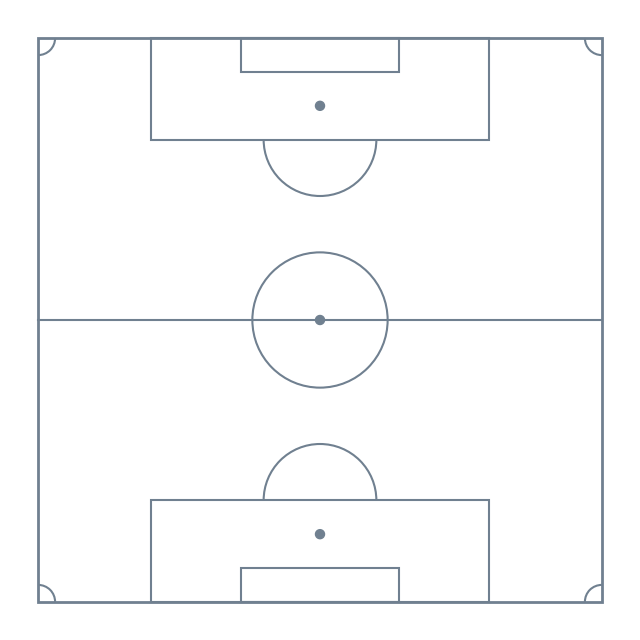

In [61]:
draw_vertical_pitch()

### PassMap Network on Pitch

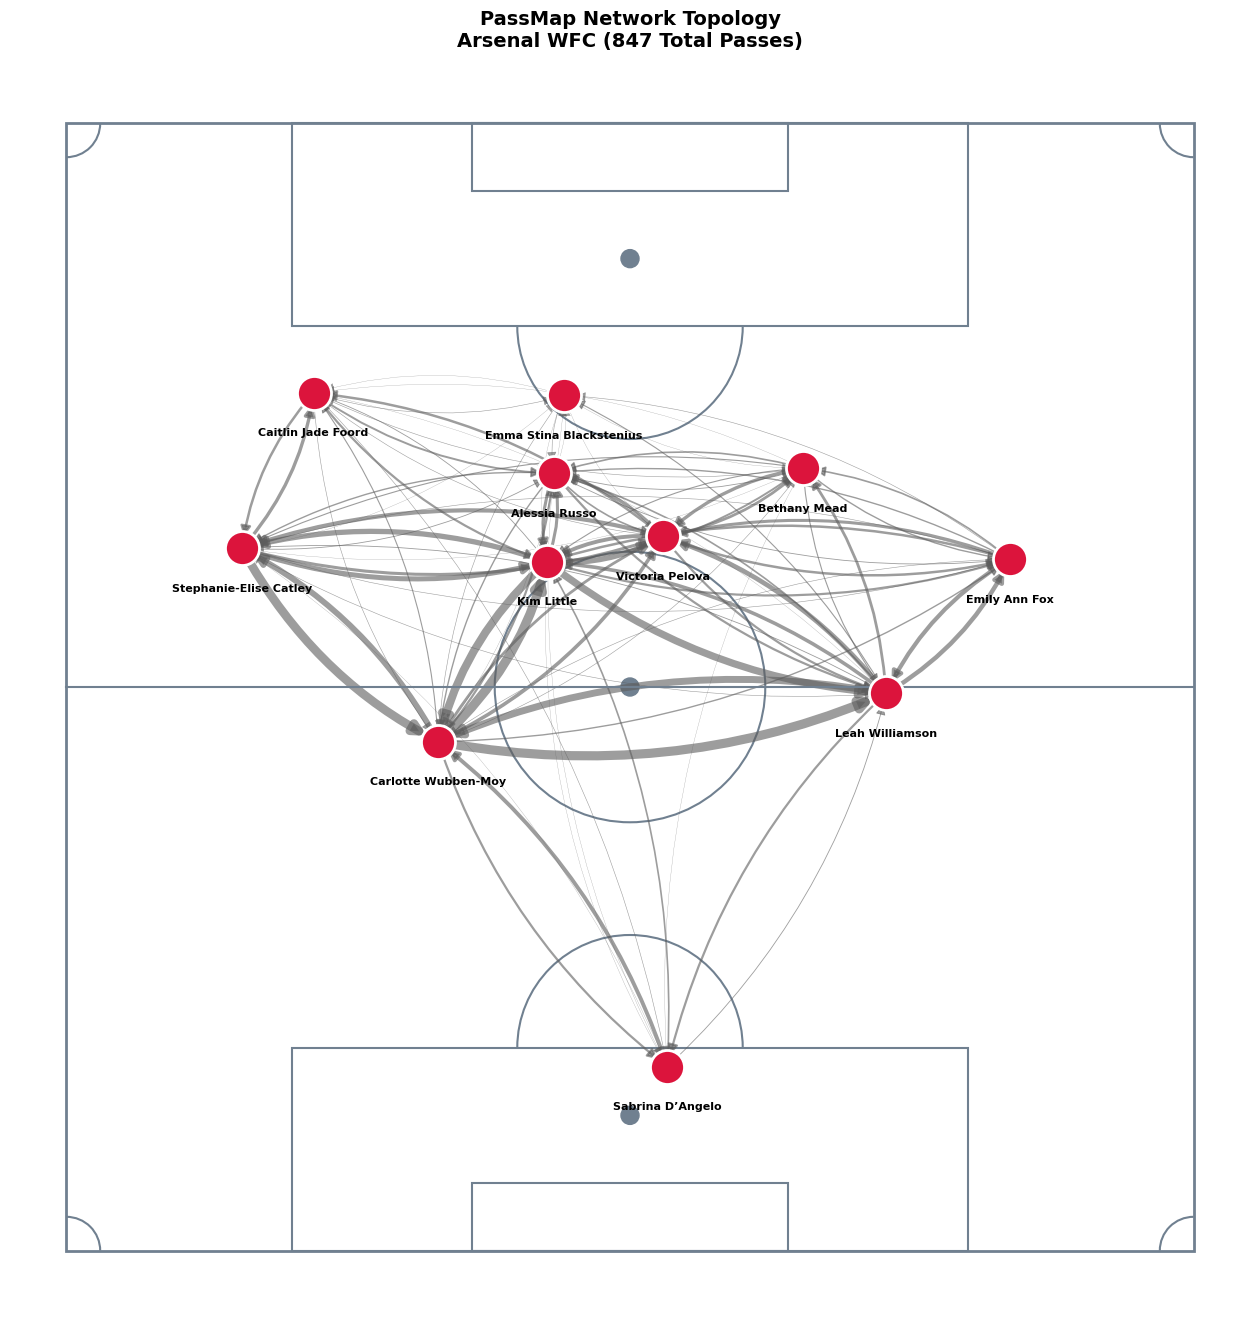

In [68]:
def plot_passmap_on_pitch(G, team_name, total_passes):
    """
    Overlays a NetworkX passmap graph onto the custom vertical pitch.
    """
    fig, ax = plt.subplots(figsize=(16, 22), facecolor='#ffffff')
    
    # 1. Draw the pitch background
    draw_vertical_pitch(ax=ax)
    
    # 2. Corrected Map Coordinates:
    # Horizontal Axis = Width (data['y'])
    # Vertical Axis   = Length (data['x']) -> Puts GK (x~0) at bottom, Strikers at top
    pos_vertical = {node: (data['y'], data['x']) for node, data in G.nodes(data=True)}
    
    # 3. Create offset position for text labels
    label_pos = {node: (coords[0], coords[1] - 3.5) for node, coords in pos_vertical.items()}
    
    # 4. Scale edge weights for arrow width
    edges = G.edges()
    weights = [G[u][v]['weight'] / 5.0 for u, v in edges]
    
    # 5. Draw Edges with Curvature
    nx.draw_networkx_edges(
        G, pos_vertical, 
        ax=ax,
        edge_color='#5c5c5c',
        alpha=0.6,
        width=weights,
        arrowsize=15,
        connectionstyle="arc3,rad=0.15" 
    )
    
    # 6. Draw Player Nodes
    nx.draw_networkx_nodes(
        G, pos_vertical, 
        ax=ax,
        node_size=600, 
        node_color='crimson',
        edgecolors='white',
        linewidths=2
    )
    
    # 7. Draw Player Name Labels
    nx.draw_networkx_labels(
        G, label_pos, 
        ax=ax,
        font_size=8, 
        font_color='black', 
        font_weight='bold'
    )
    
    # 8. Title
    plt.title(f"PassMap Network Topology\n{team_name} ({total_passes} Total Passes)", 
              fontsize=14, fontweight='bold', color='black', pad=15)
    
    plt.show()

# ==============================================================================
# EXECUTION
# ==============================================================================
plot_passmap_on_pitch(G_arsenal, highest_pass_match[2], highest_pass_match[3])

### Adjacency Matrix

In [69]:
import networkx as nx
import pandas as pd

# Convert to a labeled Pandas DataFrame
adj_df = nx.to_pandas_adjacency(G_arsenal, weight='weight', dtype=int)

print(adj_df)

                         Stephanie-Elise Catley  Sabrina D’Angelo  Emma Stina Blackstenius  Kim Little  Alessia Russo  Carlotte Wubben-Moy  Victoria Pelova  Leah Williamson  Emily Ann Fox  Caitlin Jade Foord  Bethany Mead
Stephanie-Elise Catley                        0                 0                        1          18              3                   31               11                2              2                  12             1
Sabrina D’Angelo                              1                 0                        0           6              0                   14                0                3              0                   2             0
Emma Stina Blackstenius                       0                 0                        0           1              2                    2                1                0              0                   1             1
Kim Little                                   19                 1                        0           0          

In [72]:
import networkx as nx

# Convert the weighted directed graph to a dense NumPy adjacency matrix
adj_matrix = nx.to_numpy_array(G_arsenal, weight='weight')

print(adj_matrix)

[[ 0.  0.  1. 18.  3. 31. 11.  2.  2. 12.  1.]
 [ 1.  0.  0.  6.  0. 14.  0.  3.  0.  2.  0.]
 [ 0.  0.  0.  1.  2.  2.  1.  0.  0.  1.  1.]
 [19.  1.  0.  0. 11. 29. 19. 26.  8.  3.  7.]
 [ 5.  1.  1. 11.  0.  5.  6.  8.  3.  0.  3.]
 [21.  8.  1. 33.  8.  0. 13. 33.  5.  4.  2.]
 [15.  0.  0. 14. 12. 10.  0.  8.  9.  9. 10.]
 [ 3.  8.  4. 13.  6. 25. 17.  0. 16.  1. 10.]
 [ 2.  0.  2.  9.  5.  2. 11. 15.  0.  0.  6.]
 [ 9.  0.  2.  8.  7.  2.  2.  0.  0.  0.  2.]
 [ 4.  1.  0.  4.  6.  0. 12.  4.  5.  1.  0.]]


### Next